# 1.7 Geodetic GNSS data

This notebook downloads daily GNSS position time series from the [Nevada Geodetic Laboratory](https://geodesy.unr.edu) (NGL) at the University of Nevada, Reno. NGL processes data from thousands of permanent GNSS stations worldwide and publishes daily position solutions as plain text files, one file per station.

**What the data is.** A permanent GNSS station measures its own position, every day, to a few millimeters. The time series records ground motion: steady plate tectonic drift, earthquakes (sudden offsets), slow slip events, and seasonal loading from water and snow.

**Reference frame.** We use solutions in **IGS20**, the current realization of the International Terrestrial Reference Frame adopted by the International GNSS Service. Positions are expressed relative to this global frame, so the steady trends you will see are plate motions.

**Citation.** When using NGL products, cite: Blewitt, G., Hammond, W. C., & Kreemer, C. (2018). Harnessing the GPS data explosion for interdisciplinary science. *Eos*, 99, [doi:10.1029/2018EO104623](https://doi.org/10.1029/2018EO104623).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pooch

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

## The `.tenv3` format

Each station file at `https://geodesy.unr.edu/gps_timeseries/IGS20/tenv3/IGS20/{STATION}.tenv3` is whitespace-delimited with one header line. The columns include the station name (`site`), the date (`YYMMMDD`), the decimal year (`yyyy.yyyy`), and the position components split into an integer base and a fractional part: `__east(m)`, `_north(m)`, `____up(m)` hold the varying part of the east, north, and up positions in meters. The odd-looking underscores are part of the actual column names, so we inspect the header after parsing rather than assuming it.

We use two stations from the Network of the Americas in the Pacific Northwest and northern California: **P395** and **P563**.

## Downloading with pooch — and why no pinned hash here

Section [1.6](1.6_data_gallery.md) taught the pattern: download with `pooch`, then pin the printed checksum as `known_hash` so every future run verifies it got the same bytes. That pattern applies to **frozen** files — a released dataset, an archived snapshot, the Natural Earth raster in Chapter 2.2.

These NGL files are **living data**: a new daily solution is appended every day, so the file's checksum changes every day, and a hash pinned today would fail tomorrow — by design, since the file really did change. So here we pass `known_hash=None` and instead *print* the SHA256 of what we actually received. That printed hash is your provenance record: copy it into your notes or run log, and today's analysis is tied to an exact input even though tomorrow's download will differ. If you need bit-identical reruns (a paper, a graded submission), freeze a snapshot — archive the downloaded file (Zenodo, your repo's data release) and pin *that* copy's hash.

One caching caveat: with `known_hash=None`, pooch reuses a cached copy without asking the server. Delete the `.tenv3` file from `data/` when you want today's data instead of the day you first ran this notebook.

In [2]:
BASE_URL = "https://geodesy.unr.edu/gps_timeseries/IGS20/tenv3/IGS20/{station}.tenv3"


def fetch_tenv3(station):
    """Fetch an NGL .tenv3 daily position file (cached by pooch) as a DataFrame."""
    path = pooch.retrieve(
        url=BASE_URL.format(station=station),
        known_hash=None,  # living data: NGL appends a new daily solution every day
        fname=f"{station}.tenv3",
        path=DATA_DIR,
        downloader=pooch.HTTPDownloader(timeout=120),
    )
    print(f"{station}.tenv3 sha256:{pooch.file_hash(path)}")
    # whitespace-delimited text with one header line
    return pd.read_csv(path, sep=r"\s+")


df = fetch_tenv3("P395")
print(df.columns.tolist())

P395.tenv3 sha256:75363b3d5513deebaa54f95894a5b810e8c3a6a63573e6e478b194e5468b7034
['site', 'YYMMMDD', 'yyyy.yyyy', '__MJD', 'week', 'd', 'reflon', '_e0(m)', '__east(m)', '____n0(m)', '_north(m)', 'u0(m)', '____up(m)', '_ant(m)', 'sig_e(m)', 'sig_n(m)', 'sig_u(m)', '__corr_en', '__corr_eu', '__corr_nu', '_latitude(deg)', '_longitude(deg)', '__height(m)']


In [3]:
df.head()

,site,YYMMMDD,yyyy.yyyy,__MJD,week,d,reflon,_e0(m),__east(m),____n0(m),...,_ant(m),sig_e(m),sig_n(m),sig_u(m),__corr_en,__corr_eu,__corr_nu,_latitude(deg),_longitude(deg),__height(m)
0,P395,06JAN25,2006.0671,53760,1359,3,-123.9,3347,0.560065,4987420,...,0.0083,0.000748,0.001125,0.003637,-0.053526,0.039949,-0.344025,45.022279,-123.857527,53.03951
1,P395,06JAN26,2006.0698,53761,1359,4,-123.9,3347,0.560733,4987420,...,0.0083,0.000740,0.001135,0.003557,-0.030311,0.021842,-0.308583,45.022279,-123.857527,53.03502
2,P395,06JAN27,2006.0726,53762,1359,5,-123.9,3347,0.560999,4987420,...,0.0083,0.000735,0.001120,0.003583,-0.023363,0.042888,-0.330909,45.022279,-123.857527,53.04103
3,P395,06JAN28,2006.0753,53763,1359,6,-123.9,3347,0.560352,4987420,...,0.0083,0.000756,0.001132,0.003778,-0.024996,0.024686,-0.365856,45.022279,-123.857527,53.04785
4,P395,06JAN29,2006.0780,53764,1360,0,-123.9,3347,0.560269,4987420,...,0.0083,0.000738,0.001132,0.003582,-0.041592,0.058166,-0.318254,45.022279,-123.857527,53.03961


## Relative displacement

The absolute coordinates are large numbers; what we care about is motion. We subtract the first daily solution from each component, so every series starts at zero and shows displacement in meters since the first observation. We keep the decimal year as the time axis.

In [4]:
def to_relative(df):
    """Return decimal year and east/north/up displacement (m) relative to the first epoch."""
    return pd.DataFrame(
        {
            "decimal_year": df["yyyy.yyyy"],
            "east_m": df["__east(m)"] - df["__east(m)"].iloc[0],
            "north_m": df["_north(m)"] - df["_north(m)"].iloc[0],
            "up_m": df["____up(m)"] - df["____up(m)"].iloc[0],
        }
    )


rel_p395 = to_relative(df)
rel_p395.describe()

,decimal_year,east_m,north_m,up_m
count,7418.000000,7418.000000,7418.000000,7418.000000
mean,2016.252915,-0.063444,-0.032633,-0.001993
std,5.889243,0.038632,0.021071,0.006335
min,2006.067100,-0.133928,-0.074132,-0.034824
25%,2011.162900,-0.096830,-0.050835,-0.006269
50%,2016.239550,-0.065136,-0.032732,-0.002051
75%,2021.340825,-0.028491,-0.014096,0.002220
max,2026.505100,0.003415,0.006054,0.023520


In [5]:
# download both stations and save the relative positions to ./data/
stations = ["P395", "P563"]
series = {}
for station in stations:
    rel = to_relative(fetch_tenv3(station))
    outfile = DATA_DIR / f"gps_{station}_relative_position.csv"
    rel.to_csv(outfile, index=False)
    series[station] = rel
    print(f"{station}: {len(rel)} daily solutions saved to {outfile}")

P395.tenv3 sha256:75363b3d5513deebaa54f95894a5b810e8c3a6a63573e6e478b194e5468b7034
P395: 7418 daily solutions saved to data/gps_P395_relative_position.csv
P563.tenv3 sha256:8cf6fdaeb2453da98763780a28d157cc685aa838897f4fc83bdd411a366584aa
P563: 7471 daily solutions saved to data/gps_P563_relative_position.csv


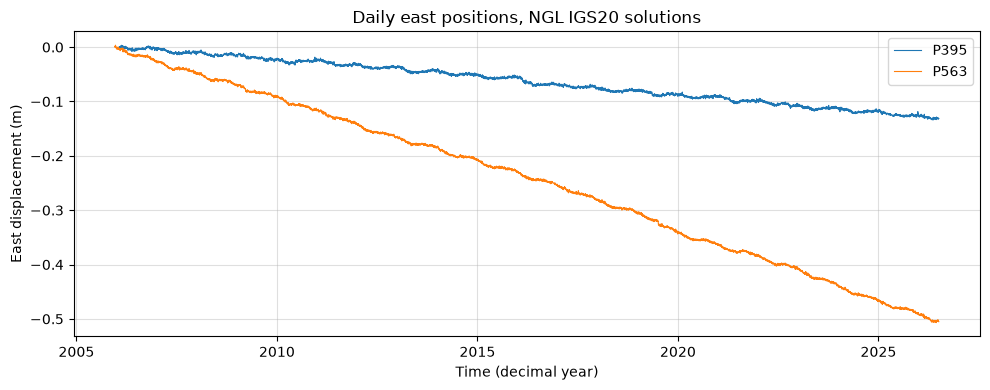

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
for station, rel in series.items():
    ax.plot(rel["decimal_year"], rel["east_m"], lw=0.8, label=station)
ax.set_xlabel("Time (decimal year)")
ax.set_ylabel("East displacement (m)")
ax.set_title("Daily east positions, NGL IGS20 solutions")
ax.grid(alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

The east components show steady, nearly linear motion of a few millimeters per year: plate tectonics measured directly. Look closely and you can also see seasonal wiggles and, depending on the station and period, small offsets from earthquakes or equipment changes. In later chapters this kind of series becomes input for trend estimation, seasonal decomposition, and forecasting exercises.

The CSV files saved in `./data/` contain only the decimal year and the three displacement components, ready for reuse.

**Data credit:** Nevada Geodetic Laboratory (Blewitt et al., 2018, doi:10.1029/2018EO104623). The data are openly distributed; cite NGL in anything you publish from them.